# DNA Search

“Search” is such a broad term that this entire book could be called Classic Search
Problems in Python.

Genes are commonly represented in computer software as a sequence of the characters A, C, G, and T. Each letter represents a nucleotide, and the combination of three nucleotides is called a codon. This is illustrated in figure 2.1. A codon codes for a specific amino acid that together with other amino acids can form a protein.

A classic task in bioinformatics software is to find a particular codon within a gene.

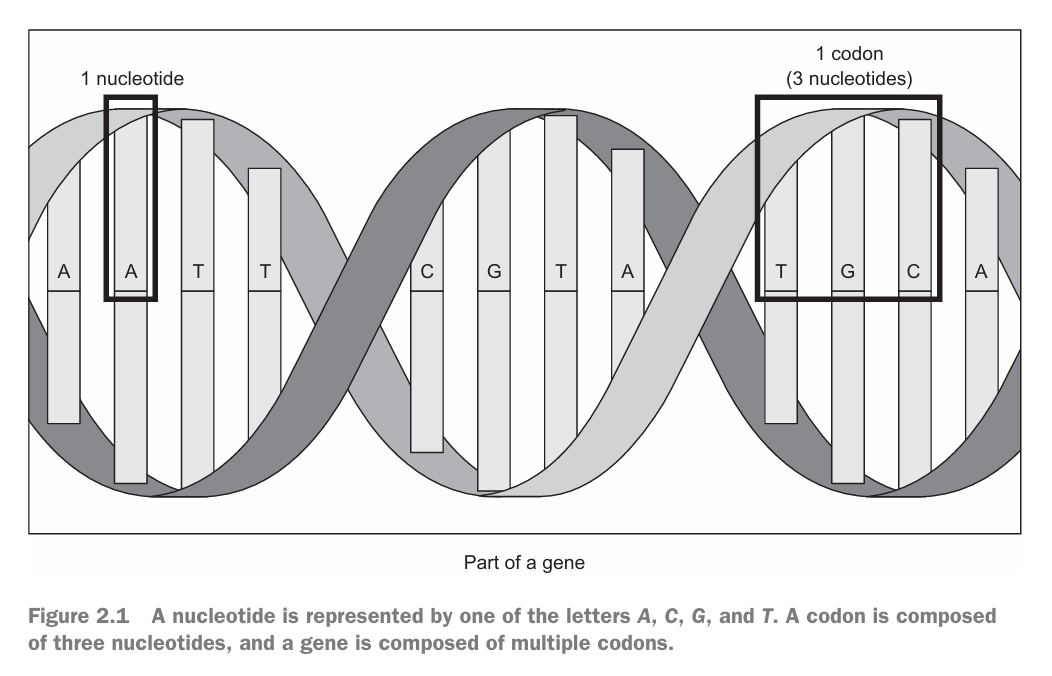

## ENUM (Overview)

An enum (short for enumeration) is a data type that contains a fixed set of named constant values.

Instead of using random numbers or strings, you use meaningful names.

### Without Enum:

In [1]:
status = "pending"

if status == "pendng":  # Typo!
    print("Waiting")

In [2]:
from enum import Enum

class Status(Enum):
    PENDING = "pending"
    APPROVED = "approved"
    REJECTED = "rejected"

status = Status.PENDING

if status == Status.PENDING:
    print("Waiting")

Waiting


### IntEnum

IntEnum is a class in Python's enum module. It allows you to create enumeration members that also behave like integers.

IntEnum is an enumeration class whose members are also integers, allowing them to be used in integer comparisons and operations.

Normal Enum:

In [3]:
from enum import Enum

class Status(Enum):
    PENDING = 1
    APPROVED = 2

print(Status.PENDING == 1)     #we need Status.PENDING.value

False


IntEnum:

In [4]:
from enum import IntEnum

class Status(IntEnum):
    PENDING = 1
    APPROVED = 2

print(Status.PENDING == 1)

True



Status.PENDING	-> Enum member

Status.PENDING.value   -> Integer value 1

In [5]:
from enum import IntEnum

class Day(IntEnum):
    MONDAY = 1
    TUESDAY = 2
    WEDNESDAY = 3
    THURSDAY = 4
    FRIDAY = 5
    SATURDAY = 6
    SUNDAY = 7


today = Day.MONDAY

print(today)
print(today.value)
print(today + 1)

1
1
2


## 1. Storing DNA

In [6]:
from enum import IntEnum
from typing import Tuple, List

# class Nucleotide(IntEnum):
#     A = 1
#     C = 2
#     G = 3
#     T = 4

#               OR

Nucleotide: IntEnum = IntEnum('Nucleotide', ('A', 'C', 'G', 'T'))

"""When you provide member names without explicit values, Python automatically assigns integer values starting from 1.
"""

'When you provide member names without explicit values, Python automatically assigns integer values starting from 1.\n'

In [7]:
"""
Codons can be defined as a tuple of three Nucleotides. A gene may be defined as a
list of Codons.
"""

Codon = Tuple[Nucleotide, Nucleotide, Nucleotide]

"""
A gene may be defined as a list of Codons.
"""

Gene = List[Codon]

In [8]:
# Testing

codon: Codon = (Nucleotide["A"], Nucleotide["C"], Nucleotide["G"])

#                       OR

# codon: Codon = (Nucleotide.A, Nucleotide.C, Nucleotide.G)

"""Nucleotide.A	-> When you know the member name directly"""
"""Nucleotide["A"] -> When you access the member using a string or variable"""


print(codon)
print("Codon Type: {}".format(type(codon)))
print(codon[0], codon[1], codon[2])

(<Nucleotide.A: 1>, <Nucleotide.C: 2>, <Nucleotide.G: 3>)
Codon Type: <class 'tuple'>
1 2 3


 genes on the internet will be in a file format that contains a giant string rep
resenting all of the nucleotides in the gene’s sequence. We will define such a string for
an imaginary gene and call it gene_str.

In [9]:
gene_str = "ACGTGGCTCTCTAACGTACGTACGTACGGGGTTTATATATACCCTAGGACTCCCTTT"

In [10]:
"""Convert Str -> Gene"""

def string_to_gene(s: str) -> Gene:
    gene: Gene = []

    for i in range(0, len(s), 3):
        if (i+2) >= len(s):
            return gene

        codon: Codon = (Nucleotide[s[i]], Nucleotide[s[i+1]], Nucleotide[s[i+2]])
        gene.append(codon)

    return gene


In [11]:
my_gene: Gene = string_to_gene(gene_str)

print(my_gene)
print("Gene Length: {} ".format(len(my_gene)))

print(my_gene[0])

print(len(my_gene[0]))

print(my_gene[0][0])

my_gene[0][0].value


[(<Nucleotide.A: 1>, <Nucleotide.C: 2>, <Nucleotide.G: 3>), (<Nucleotide.T: 4>, <Nucleotide.G: 3>, <Nucleotide.G: 3>), (<Nucleotide.C: 2>, <Nucleotide.T: 4>, <Nucleotide.C: 2>), (<Nucleotide.T: 4>, <Nucleotide.C: 2>, <Nucleotide.T: 4>), (<Nucleotide.A: 1>, <Nucleotide.A: 1>, <Nucleotide.C: 2>), (<Nucleotide.G: 3>, <Nucleotide.T: 4>, <Nucleotide.A: 1>), (<Nucleotide.C: 2>, <Nucleotide.G: 3>, <Nucleotide.T: 4>), (<Nucleotide.A: 1>, <Nucleotide.C: 2>, <Nucleotide.G: 3>), (<Nucleotide.T: 4>, <Nucleotide.A: 1>, <Nucleotide.C: 2>), (<Nucleotide.G: 3>, <Nucleotide.G: 3>, <Nucleotide.G: 3>), (<Nucleotide.G: 3>, <Nucleotide.T: 4>, <Nucleotide.T: 4>), (<Nucleotide.T: 4>, <Nucleotide.A: 1>, <Nucleotide.T: 4>), (<Nucleotide.A: 1>, <Nucleotide.T: 4>, <Nucleotide.A: 1>), (<Nucleotide.T: 4>, <Nucleotide.A: 1>, <Nucleotide.C: 2>), (<Nucleotide.C: 2>, <Nucleotide.C: 2>, <Nucleotide.T: 4>), (<Nucleotide.A: 1>, <Nucleotide.G: 3>, <Nucleotide.G: 3>), (<Nucleotide.A: 1>, <Nucleotide.C: 2>, <Nucleotide.T: 4

1

In [12]:
my_gene[0][0]

<Nucleotide.A: 1>

## Note

### Jupyter uses the object's representation (repr()), while print() uses its string representation (str()).

1) Using print(my_gene[0][0]) 

Python explicitly displays the value.

Output: Nucleotide.A,  i.e equal 1

2) Writing the expression alone my_gene[0][0]

In Jupyter Notebook, the last expression in a cell is automatically displayed.

Output:

<Nucleotide.A: 1>

In [13]:
gene_value = []
for i in range(len(my_gene)):
    nucleotide_value = []
    for j in range(len(my_gene[i])):
        nucleotide_value.append(my_gene[i][j].value)
    gene_value.append(nucleotide_value)

print(gene_value)

[[1, 2, 3], [4, 3, 3], [2, 4, 2], [4, 2, 4], [1, 1, 2], [3, 4, 1], [2, 3, 4], [1, 2, 3], [4, 1, 2], [3, 3, 3], [3, 4, 4], [4, 1, 4], [1, 4, 1], [4, 1, 2], [2, 2, 4], [1, 3, 3], [1, 2, 4], [2, 2, 2], [4, 4, 4]]


In [14]:
print(len(gene_value))

19


## Linear Search

One basic operation we may want to perform on a gene is to search it for a particular
codon. The goal is to simply find out whether the codon exists within the gene or not

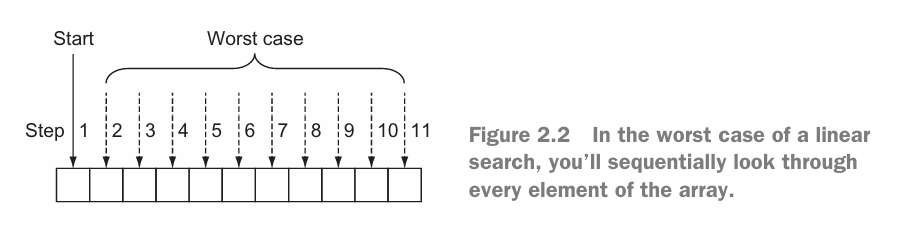

In [15]:
def linearSearch(gene: Gene, key_codon: Codon) -> bool:
    for codon in gene:
        if codon == key_codon:
            return True

    return False

In [16]:
acg: Codon = (Nucleotide.A, Nucleotide.C, Nucleotide.G)
gat: Codon = (Nucleotide.G, Nucleotide.A, Nucleotide.T)

print(linearSearch(my_gene, acg))
print(linearSearch(my_gene, gat))

True
False


### Note

This function is for illustrative purposes only. The Python built-in
sequence types (list, tuple, range) all implement the __contains__()
method, which allows us to do a search for a specific item in them by simply
using the in operator. In fact, the in operator can be used with any type that
implements __contains__(). For instance, we could search my_gene for acg
and print out the result by writing print(acg in my_gene). 

## Binary Search

In [17]:
def binarySearch(gene: Gene, key_codon: Codon) -> bool:
    low: int = 0
    high: int = len(my_gene) - 1

    while(low < high):
        mid: int = low + (high - low) // 2      # prevents integer overflow

        if gene[mid] < key_codon:
            low = mid + 1

        elif gene[mid] > key_codon:
            high = mid - 1

        else:
            return True

    return False

In [18]:
my_sorted_gene: Gene = sorted(my_gene)
print(binarySearch(my_sorted_gene, acg))
print(binarySearch(my_sorted_gene, gat))

True
False
